# Minkowski post-tunneling evolution from 2D Euclidean solution

This notebook tests **Minkowskian time evolution** after tunneling, using initial data taken from the **2D Euclidean** solution at $\tau = 0$.

## Analytic continuation and initial conditions

With $t = -i\tau$ we have $\partial_t = i\partial_\tau$. So at Minkowski time $t = 0$:

- $\phi(t=0,r) = \phi_E(\tau=0,r)$ and $\bar{\phi}(t=0,r) = \bar{\phi}_E(\tau=0,r)$
- $\partial_t \phi(t=0,r) = i (\partial_\tau \phi_E)|_{\tau=0}$ and $\partial_t \bar{\phi}(t=0,r) = i (\partial_\tau \bar{\phi}_E)|_{\tau=0}$

This is the key relation: the Minkowski time derivative at $t=0$ is $i$ times the Euclidean $\tau$-derivative at $\tau=0$.

## Minkowski equations of motion (spherical 1D)

For a complex field with potential $V(\rho)$, $\rho^2 = \phi\bar{\phi}$:

$$\ddot{\phi} = \partial_r^2\phi + \frac{2}{r}\partial_r\phi - \frac{\partial V}{\partial\bar{\phi}}, \qquad \ddot{\bar{\phi}} = \partial_r^2\bar{\phi} + \frac{2}{r}\partial_r\bar{\phi} - \frac{\partial V}{\partial\phi}$$

With $V = U(\rho)$ and $\rho = \sqrt{\mathrm{Re}(\phi\bar{\phi})}$: $\frac{\partial V}{\partial\bar{\phi}} = \frac{dU}{d\rho}\frac{\phi}{2\rho}$, and similarly for $\phi$.

## Energy and charge

- **Energy:** $E = 4\pi \int dr\, r^2 [T + G + V]$, with $T = |\partial_t\phi|^2$, $G = (\partial_r\phi)(\partial_r\bar{\phi})$, $V = U(\rho)$.
- **Charge:** $j^0 = i(\bar{\phi}\,\partial_t\phi - \partial_t\bar{\phi}\,\phi)$, $Q = 4\pi \int dr\, r^2 \frac{1}{2}\mathrm{Re}(j^0)$, same convention as `observables_2d`.

## Configurable parameters

Set project path, potential parameters ($\phi_0$, $V_1$, $V_2$), $\omega$, and 2D/Minkowski grid and evolution options.

In [1]:
# =============================================================================
# Project path and configurable parameters
# =============================================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model (same as Final_Bubble_2D)
PHI0 = 1.999
V1 = 1.0
V2 = 2.0
OMEGA = 0.85

# 2D Euclidean grid (single "easy" point)
Nr_2d = 60
Ntau_2d = 80
Lr_2d = 5.0
beta_2d = 20.0

# Minkowski evolution
t_max = 20.0
dt_mink = None   # None => 0.2*dr
save_every_n = 10
sponge_fraction = 0.1
sponge_gamma = 0.02

# Outputs
OUT_DIR = PROJECT_ROOT / "outputs" / "minkowski"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_2D = PROJECT_ROOT / "outputs"
OUT_2D.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"φ0={PHI0}, V1={V1}, V2={V2}, ω={OMEGA}")
print(f"2D grid: Nr={Nr_2d}, Nτ={Ntau_2d}, Lr={Lr_2d}, β={beta_2d}")
print(f"Minkowski: t_max={t_max}, out={OUT_DIR}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
φ0=1.999, V1=1.0, V2=2.0, ω=0.85
2D grid: Nr=60, Nτ=80, Lr=5.0, β=20.0
Minkowski: t_max=20.0, out=/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/outputs/minkowski


## Imports and potential

Import Bubble_finder (potential, 2D solver, ansatz) and the Minkowski evolution module. The potential is $U(\rho) = V(\phi)$.

In [15]:
# =============================================================================
# Imports and potential U(ρ) = V(φ)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2, vacua_of_Omega
from Bubble_finder.bounce2d import (
    Bubble2DSettings,
    Bubble2DSolver,
    make_potential_from_V,
    solve_rho0_for_omega,
)
from Bubble_finder.minkowski_evolution_post_tunneling import (
    extract_initial_data_from_euclidean,
    run_minkowski_evolution,
    compute_energy,
    compute_charge,
)

U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

# Math and fonts in plots: use mathtext (no LaTeX required); labels with $...$ still render correctly
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
plt.rcParams["figure.figsize"] = (8, 6)

print("Imports and potential OK.")

Imports and potential OK.


## Obtain 2D Euclidean solution

Either load a precomputed 2D solution from `outputs/2d_solution_point.npz` or run Newton from a homogeneous or gated ansatz, then save. We use a single "easy" parameter point ($\omega = \mathrm{OMEGA}$, small grid).

In [3]:
# =============================================================================
# Load or solve 2D Euclidean solution
# =============================================================================
path_2d = OUT_2D / "2d_solution_point.npz"
use_saved = path_2d.exists()

if use_saved:
    data = np.load(path_2d, allow_pickle=True)
    tau_grid = np.asarray(data["tau_grid"]).flatten()
    r_grid_2d = np.asarray(data["r_grid"]).flatten()
    phi_2d = np.asarray(data["phi"], dtype=complex)
    phi_bar_2d = np.asarray(data["phi_bar"], dtype=complex)
    print(f"Loaded 2D solution from {path_2d}")
    print(f"  tau_grid shape {tau_grid.shape}, r_grid shape {r_grid_2d.shape}, phi shape {phi_2d.shape}")
else:
    from Bubble_finder.bounce_1d import solve_bounce
    from Bubble_finder.ansatz_bubble import tau_gate, AnsatzParams

    # Same workflow as Final_Bubble_2D: compute 1D bounce first, then use its extent for 2D grid
    omega_2d_g = float(OMEGA)
    Nr_2d_g, Ntau_2d_g = Nr_2d, Ntau_2d
    beta_2d_g = beta_2d
    rho_false_2d_g, _ = vacua_of_Omega(PHI0, V1, V2, omega_2d_g)
    rho0_2d_g = float(rho_false_2d_g)

    # 1D bounce at omega_2d_g (same as Final_Bubble_2D: RMAX for 1D solve, then Lr_2d = r_bounce[-1])
    RMAX_1d = 20.0
    r_1d_g, phi_1d_g, _, _, _ = solve_bounce(
        PHI0, V1, V2, omega_2d_g,
        d=3, r0=1e-6, rmax=RMAX_1d, max_iter=150, verbose=False,
    )
    if r_1d_g is None or len(r_1d_g) == 0:
        raise RuntimeError("1D bounce failed; cannot build 2D ansatz.")
    r_1d_g = np.asarray(r_1d_g, float)
    phi_1d_g = np.asarray(phi_1d_g, float)
    Lr_2d_g = float(r_1d_g[-1])
    print(f"Gated 2D run: omega = {omega_2d_g:.6f}, 1D r_max = {Lr_2d_g:.4f}, Lr_2d = {Lr_2d_g:.4f}")

    settings_2d_g = Bubble2DSettings(
        Nr=Nr_2d_g, Ntau=Ntau_2d_g, Lr=Lr_2d_g, beta=beta_2d_g,
        omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
        newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
    )
    solver_2d_g = Bubble2DSolver(settings_2d_g, U, dU, d2U)

    # Gated ansatz: 1D profile x tau gate (same as Final_Bubble_2D)
    r_grid_g = np.asarray(solver_2d_g.grid.r).flatten()
    tau_grid_g = np.asarray(solver_2d_g.grid.tau).flatten()
    T_g = beta_2d_g / 2.0
    params_gated = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
    phi_on_r_g = np.interp(r_grid_g, r_1d_g, phi_1d_g, left=phi_1d_g[0], right=phi_1d_g[-1])
    y_slice_g = r_grid_g * (phi_on_r_g - solver_2d_g.rho0)
    g_tau = tau_gate(tau_grid_g, T_g, params_gated.tau_gate_frac, center_frac=params_gated.tau_gate_center_frac)
    y_gated = params_gated.amp * np.outer(y_slice_g, g_tau).astype(complex)
    ybar_gated = y_gated.copy()
    x0_gated = solver_2d_g.pack(y_gated, ybar_gated)

    try:
        sol_2d_g = solver_2d_g.solve(x0_gated, verbose=True, verbose_success_block=False)
    except Exception as e:
        print(f"Gated solve failed: {e}. Falling back to homogeneous ansatz.")
        x0_hom = solver_2d_g._zero_vec()
        sol_2d_g = solver_2d_g.solve(x0_hom, verbose=True, verbose_success_block=False)

    phi_2d, phi_bar_2d = solver_2d_g.phi(sol_2d_g.y, sol_2d_g.ybar)
    tau_grid = np.asarray(solver_2d_g.grid.tau).flatten()
    r_grid_2d = np.asarray(solver_2d_g.grid.r).flatten()
    np.savez(
        path_2d,
        tau_grid=tau_grid,
        r_grid=r_grid_2d,
        phi=phi_2d,
        phi_bar=phi_bar_2d,
    )
    print(f"Saved 2D solution to {path_2d}")

# Ensure (Nr, Nt) layout: r along rows, tau along columns
if phi_2d.shape[0] != len(r_grid_2d):
    phi_2d = phi_2d.T
    phi_bar_2d = phi_bar_2d.T
assert phi_2d.shape[0] == len(r_grid_2d) and phi_2d.shape[1] == len(tau_grid)

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01


Gated 2D run: omega = 0.850000, 1D r_max = 3.7058, Lr_2d = 3.7058
[Newton-explicit] iter=01, ||F||=7.626e+00, rhoQ=9.765997e-01, rhoE=-4.054848e-01, rho_Q/rho_Q_ref=1.0129, rho_E/rho_E_ref=1.0722
[Newton-explicit] iter=02, ||F||=4.378e+00, rhoQ=9.718996e-01, rhoE=-4.016739e-01, rho_Q/rho_Q_ref=1.0080, rho_E/rho_E_ref=1.0621
[Newton-explicit] iter=03, ||F||=1.667e+00, rhoQ=9.667269e-01, rhoE=-3.946871e-01, rho_Q/rho_Q_ref=1.0027, rho_E/rho_E_ref=1.0436
[Newton-explicit] iter=04, ||F||=8.822e-02, rhoQ=9.663335e-01, rhoE=-3.934701e-01, rho_Q/rho_Q_ref=1.0023, rho_E/rho_E_ref=1.0404
[Newton-explicit] iter=05, ||F||=1.934e-04, rhoQ=9.663428e-01, rhoE=-3.934688e-01, rho_Q/rho_Q_ref=1.0023, rho_E/rho_E_ref=1.0404
[Newton-explicit] iter=06, ||F||=3.316e-09, rhoQ=9.663428e-01, rhoE=-3.934687e-01, rho_Q/rho_Q_ref=1.0023, rho_E/rho_E_ref=1.0404
Saved 2D solution to /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/outputs/2d_solution_point.npz


[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01


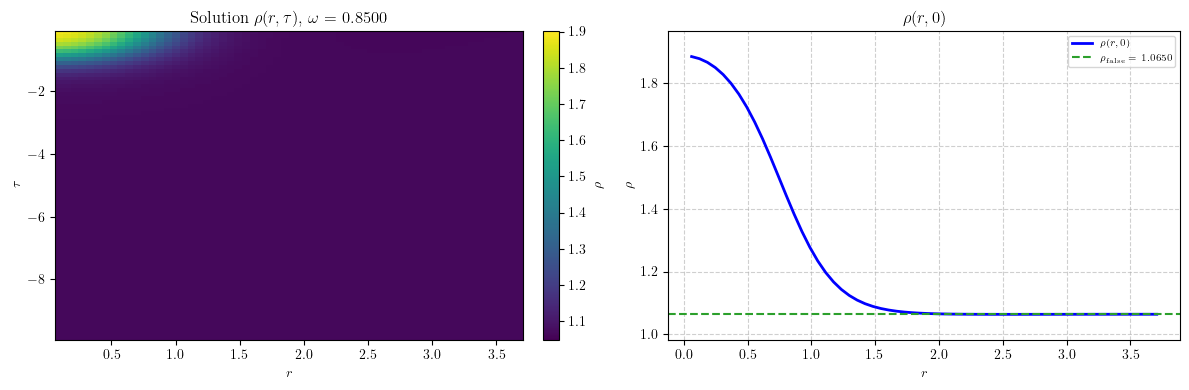

In [16]:
# =============================================================================
# Plot 2D solution: same style as Final_Bubble_2D gated cell, 2 panels only
# (1) rho(r,tau) heatmap  (2) rho(r) at tau=0 with rho_false
# =============================================================================
rho_eps = 1e-14
u_2d = (phi_2d * phi_bar_2d).real
rho_2d = np.sqrt(np.maximum(u_2d, 0.0) + rho_eps)

rho_false_plot, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
rho_false_plot = float(rho_false_plot)

# Color scale from data + 2% margin (as in Final_Bubble_2D)
vmin_rho = float(np.min(rho_2d))
vmax_rho = float(np.max(rho_2d))
delta_rho = max(vmax_rho - vmin_rho, 1e-10)
vmin_rho -= 0.02 * delta_rho
vmax_rho += 0.02 * delta_rho

# Sort by tau for 2D display
tau_min_plot = float(np.min(tau_grid))
tau_max_plot = float(np.max(tau_grid))
extent_r_tau = (float(r_grid_2d[0]), float(r_grid_2d[-1]), tau_min_plot, tau_max_plot)
rho_sorted = rho_2d[:, np.argsort(tau_grid)].T

idx_tau0_plot = np.argmax(tau_grid)
rho_at_tau0 = rho_2d[:, idx_tau0_plot]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
im1 = ax1.imshow(rho_sorted, origin="lower", aspect="auto", extent=extent_r_tau, vmin=vmin_rho, vmax=vmax_rho)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Solution $\rho(r,\tau)$, $\omega$ = " + f"{OMEGA:.4f}")

ax2.plot(r_grid_2d, rho_at_tau0, "b-", lw=2, label=r"$\rho(r,0)$")
ax2.axhline(rho_false_plot, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_plot:.4f}")
ymin_3 = min(rho_at_tau0.min(), rho_false_plot)
ymax_3 = max(rho_at_tau0.max(), rho_false_plot)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax2.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax2.set_xlabel(r"$r$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r,0)$")
ax2.legend(loc="best", fontsize=7)
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Extract Minkowski initial data at $\tau = 0$

Use `extract_initial_data_from_euclidean`: slice $\phi$, $\bar{\phi}$ at $\tau \approx 0$ and set $\partial_t\phi = i\partial_\tau\phi_E$ (and conjugate). Diagnostic: $\max|\bar{\phi}_0 - \mathrm{conj}(\phi_0)|$.

In [17]:
# =============================================================================
# Extract initial data: phi0, phi_bar0, dotphi0, dotphi_bar0
# =============================================================================
r_grid, phi0, phi_bar0, dotphi0, dotphi_bar0 = extract_initial_data_from_euclidean(
    phi_2d,
    phi_bar_2d,
    tau_grid,
    r_grid_2d,
    verbose=True,
)

# Save initial data
np.savez(
    OUT_DIR / "initial_data.npz",
    r_grid=r_grid,
    phi0=phi0,
    phi_bar0=phi_bar0,
    dotphi0=dotphi0,
    dotphi_bar0=dotphi_bar0,
)
print(f"Saved initial_data.npz to {OUT_DIR}")

[extract_initial_data] tau index i0=0, tau0=-0.0625; max|φ̄0 − conj(φ0)| = 1.507e-01
Saved initial_data.npz to /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/outputs/minkowski


## Run Minkowski evolution

Evolve with velocity Verlet; optional sponge at the outer boundary. Record $E(t)$, $Q(t)$ and snapshots at chosen times.

In [18]:
# =============================================================================
# Minkowski evolution
# =============================================================================
t_snap = (0.0, 2.0, 5.0, 8.0, 12.0, 16.0, 20.0)
t_snap = tuple(t for t in t_snap if t <= t_max)

t_arr, E_arr, Q_arr, r_ev, snapshots = run_minkowski_evolution(
    r_grid,
    phi0,
    phi_bar0,
    dotphi0,
    dotphi_bar0,
    U,
    dU,
    t_max=t_max,
    dt=dt_mink,
    sponge_fraction=sponge_fraction,
    sponge_gamma=sponge_gamma,
    save_every_n=save_every_n,
    snapshot_times=t_snap,
    verbose=True,
)

# Build snapshot arrays for saving (t, r, rho)
rho_eps = 1e-14
snap_times = []
snap_rho = []
for t, ph, phb in snapshots:
    u = (ph * phb).real
    rho = np.sqrt(np.maximum(u, 0.0) + rho_eps)
    snap_times.append(t)
    snap_rho.append(rho)
snap_times = np.array(snap_times)
snap_rho = np.array(snap_rho) if snap_rho else np.empty((0, len(r_ev)))

np.savez(
    OUT_DIR / "evolution.npz",
    t_arr=t_arr,
    E_arr=E_arr,
    Q_arr=Q_arr,
    r_grid=r_ev,
    snap_times=snap_times,
    snap_rho=snap_rho,
)
print(f"Saved evolution.npz to {OUT_DIR}")

# Drift summary
E0, Q0 = E_arr[0], Q_arr[0]
drift_E_abs = np.max(np.abs(E_arr - E0))
drift_E_rel = drift_E_abs / (abs(E0) + 1e-30)
drift_Q_abs = np.max(np.abs(Q_arr - Q0))
drift_Q_rel = drift_Q_abs / (abs(Q0) + 1e-30)
print(f"E: max|ΔE| = {drift_E_abs:.3e}, max|ΔE/E0| = {drift_E_rel:.3e}")
print(f"Q: max|ΔQ| = {drift_Q_abs:.3e}, max|ΔQ/Q0| = {drift_Q_rel:.3e}")

[run_minkowski_evolution] dt = 0.2*dr = 0.01235 (dr=0.06176)


/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/potential_bubble.py:127: RuntimeWarning: overflow encountered in multiply
  2.0 * (phi_flat - v1) * (term2 + term3 * log_term)
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/potential_bubble.py:128: RuntimeWarning: overflow encountered in multiply
  + term1 * (2.0 - 2.0 * (v2 - phi_flat) * log_term + term3 * dlog_dphi)
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/minkowski_evolution_post_tunneling.py:157: RuntimeWarning: invalid value encountered in divide
  coeff = dU_rho / (2.0 * rho)
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/potential_bubble.py:63: RuntimeWarning: overflow encountered in multiply
  V = -0.5 + (phi_flat - v1) ** 2 * (2.0 * phi_flat - 5.0 + (v2 - phi_flat) ** 2 * log_term)
/home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bub

[run_minkowski_evolution] E: max|ΔE|=nan, max|ΔE/E0|=nan
[run_minkowski_evolution] Q: max|ΔQ|=nan, max|ΔQ/Q0|=nan
Saved evolution.npz to /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/outputs/minkowski
E: max|ΔE| = nan, max|ΔE/E0| = nan
Q: max|ΔQ| = nan, max|ΔQ/Q0| = nan


/tmp/ipykernel_99299/3566280856.py:29: RuntimeWarning: overflow encountered in multiply
  u = (ph * phb).real


## Snapshots: $\rho(t,r)$ vs $r$

Plot $|\phi|$ (or $\rho = \sqrt{\mathrm{Re}(\phi\bar{\phi})}$) at several times to show the bubble wall moving outward (expansion).

/tmp/ipykernel_99299/1434091901.py:6: RuntimeWarning: overflow encountered in multiply
  u = (ph * phb).real


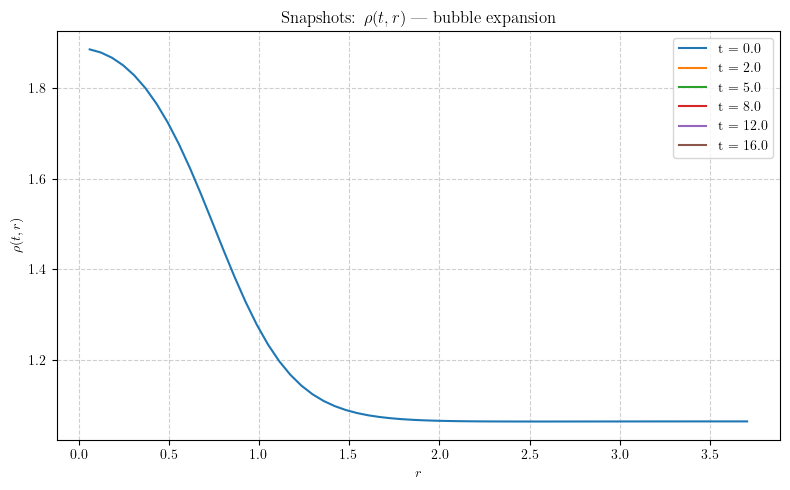

In [19]:
# =============================================================================
# Snapshots: rho(t,r) vs r
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for i, (t, ph, phb) in enumerate(snapshots):
    u = (ph * phb).real
    rho = np.sqrt(np.maximum(u, 0.0) + 1e-14)
    ax.plot(r_ev, rho, label=f"t = {t:.1f}", lw=1.5)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho(t,r)$")
ax.set_title(r"Snapshots: $\rho(t,r)$ — bubble expansion")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / "snapshots_rho.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Energy and charge conservation

Plot $E(t)/E(0) - 1$ and $Q(t)/Q(0) - 1$ vs $t$.

In [ ]:
# =============================================================================
# E(t)/E(0) - 1 and Q(t)/Q(0) - 1 vs t
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
E0, Q0 = E_arr[0], Q_arr[0]
ax1.plot(t_arr, E_arr / (E0 + 1e-30) - 1.0, "b-", lw=1.5, label=r"$E(t)/E(0)-1$")
ax1.set_ylabel(r"$E(t)/E(0) - 1")
ax1.set_title("Energy drift")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)
ax2.plot(t_arr, Q_arr / (abs(Q0) + 1e-30) - 1.0, "b-", lw=1.5, label=r"$Q(t)/Q(0)-1$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$Q(t)/Q(0) - 1")
ax2.set_title("Charge drift")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / "energy_charge_drift.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Optional: heatmap $\rho(t,r)$

Space-time plot of $\rho(t,r)$ to visualize expansion.

In [ ]:
# =============================================================================
# Heatmap rho(t,r)
# =============================================================================
# Interpolate full evolution to a regular (t,r) grid for display (use stored t_arr and r_ev)
# We only have snapshots at t_snap; for a denser heatmap we could store rho at every save_every_n step.
# Here we show snapshots as rows.
if len(snap_times) > 0 and snap_rho.size > 0:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    extent = (float(r_ev[0]), float(r_ev[-1]), float(snap_times[0]), float(snap_times[-1]))
    im = ax.imshow(
        snap_rho,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
    )
    plt.colorbar(im, ax=ax, label=r"$\rho$")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$t$")
    ax.set_title(r"$\rho(t,r)$ (snapshots)")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "heatmap_rho.pdf", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No snapshots to plot heatmap.")